## House Price Predictor using Different Models
In this notebook, I will use different models to create House Price Predictor and evaluate their performance.

## Import Packages

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import sklearn
from sklearn import metrics
import tensorflow as tf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

## Import Datasets

In [2]:
train = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")

test = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")


## Common Functions

**Evaluation Function**

In [3]:
def evaluate(model, x_val, y_val):
    y_pred = model.predict(x_val)
    r2 = metrics.r2_score(y_val, y_pred)
    mse = metrics.mean_squared_error(y_val, y_pred)
    mae = metrics.mean_absolute_error(y_val, y_pred)
    msle = metrics.mean_squared_log_error(y_val, y_pred)
    mape = np.mean(tf.keras.metrics.mean_absolute_percentage_error(y_val, y_pred).numpy())
    rmse = np.sqrt(mse)
    rmlse_score = rmlse(y_val, y_pred).numpy()
    print("R2 Score:", r2)
    print("MSE:", mse)
    print("MAE:", mae)
    print("MSLE:", msle)
    print("MAPE", mape)
    print("RMSE:", rmse)
    print("RMLSE", rmlse_score)
    return {"r2": r2, "mse": mse, "mae": mae, "msle": msle, "mape": mape, "rmse": rmse, "rmlse": rmlse_score}

**Export Results**

In [4]:
def export_result(model, df, file_path, features = None):
    if features == None:
        x = df
    else:
        x = df[features]
    SalePrice = model.predict(x)
    submission = pd.DataFrame({"Id": df["Id"], "SalePrice": SalePrice.reshape(-1)})
    submission.to_csv(file_path, index=False)

**Root Mean Squared Logarithmic Error**

In [5]:
def rmlse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(tf.math.log(y_pred + 1) - tf.math.log(y_true + 1))))

## Exploratory Data Analysis

**First 5 rows**

In [6]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Its shape**

In [7]:
train.shape

(1460, 81)

**Statistic infos**

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [9]:
train[train.columns[train.dtypes==object]].value_counts()

Series([], dtype: int64)

In [10]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Correlation scores**

In [11]:
correlation_scores = train.corr()
correlation_scores

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


**Factors that impact house price most**

In [12]:
train.corr()["SalePrice"].sort_values(key = lambda x: abs(x), ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
ScreenPorch      0.111447
PoolArea         0.092404
MSSubClass      -0.084284
OverallCond     -0.077856
MoSold           0.046432
3SsnPorch        0.044584
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
Name: SalePr

## Data Cleaning

**Features that contains missing values**

In [13]:
null_counts = train.isnull().sum()
null_counts[null_counts > 0]

LotFrontage      259
Alley           1369
MasVnrType         8
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [14]:
null_columns = list(pd.DataFrame(null_counts[null_counts > 0]).index)

**Features that has missing values**

In [15]:
train[null_columns].dtypes

LotFrontage     float64
Alley            object
MasVnrType       object
MasVnrArea      float64
BsmtQual         object
BsmtCond         object
BsmtExposure     object
BsmtFinType1     object
BsmtFinType2     object
Electrical       object
FireplaceQu      object
GarageType       object
GarageYrBlt     float64
GarageFinish     object
GarageQual       object
GarageCond       object
PoolQC           object
Fence            object
MiscFeature      object
dtype: object

**Solve Missing values for Training Set**

I will use following strategies to apply imputation to missing values. 
- For numerical columns, I will replace missing value with their median value.
- For categorical columns, I will replace missing value with unknown, which is a new category.

In [16]:
for column in null_columns:
    if train[column].dtype == object:
        train[column] = train[[column]].replace(np.NAN, "Unknown")
    else:
        train[column] = train[column].replace(np.NAN, train[column].median())

**Do the same for Test data set**

In [17]:
null_counts = test.isnull().sum()
null_counts[null_counts > 0]
null_columns = list(pd.DataFrame(null_counts[null_counts > 0]).index)
for column in null_columns:
    if test[column].dtype == object:
        test[column] = test[[column]].replace(np.NAN, test[column].mode()[0])
    else:
        test[column] = test[column].replace(np.NAN, test[column].median())

**Now the data are all non-nulls**

In [18]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

**Convert categorical features to one hot vector**

In [19]:
train_test_dummied = pd.get_dummies(pd.concat([train, test]))

In [20]:
train_test_dummied.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706.0,...,0,0,0,1,0,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978.0,...,0,0,0,1,0,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486.0,...,0,0,0,1,0,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216.0,...,0,0,0,1,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655.0,...,0,0,0,1,0,0,0,0,1,0


In [21]:
mean_value = train_test_dummied.mean()
std_value = train_test_dummied.std()
print(mean_value)
print(std_value)

Id                        1460.000000
MSSubClass                  57.137718
LotFrontage                 69.099349
LotArea                  10168.114080
OverallQual                  6.089072
                             ...     
SaleCondition_AdjLand        0.004111
SaleCondition_Alloca         0.008222
SaleCondition_Family         0.015759
SaleCondition_Normal         0.822885
SaleCondition_Partial        0.083933
Length: 306, dtype: float64
Id                        842.787043
MSSubClass                 42.517628
LotFrontage                21.321241
LotArea                  7886.996359
OverallQual                 1.409947
                            ...     
SaleCondition_AdjLand       0.063996
SaleCondition_Alloca        0.090317
SaleCondition_Family        0.124562
SaleCondition_Normal        0.381832
SaleCondition_Partial       0.277335
Length: 306, dtype: float64


In [22]:
mean_value.pop("SalePrice")
std_value.pop("SalePrice")

79442.50288288663

In [23]:
train_dummied = train_test_dummied.iloc[0: len(train)]
test_dummied = train_test_dummied.iloc[len(train):]
_ = test_dummied.pop("SalePrice")
train_dummied.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706.0,...,0,0,0,1,0,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978.0,...,0,0,0,1,0,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486.0,...,0,0,0,1,0,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216.0,...,0,0,0,1,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655.0,...,0,0,0,1,0,0,0,0,1,0


In [24]:
test_dummied.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1461,20,80.0,11622,5,6,1961,1961,0.0,468.0,...,0,0,0,1,0,0,0,0,1,0
1,1462,20,81.0,14267,6,6,1958,1958,108.0,923.0,...,0,0,0,1,0,0,0,0,1,0
2,1463,60,74.0,13830,5,5,1997,1998,0.0,791.0,...,0,0,0,1,0,0,0,0,1,0
3,1464,60,78.0,9978,6,6,1998,1998,20.0,602.0,...,0,0,0,1,0,0,0,0,1,0
4,1465,120,43.0,5005,8,5,1992,1992,0.0,263.0,...,0,0,0,1,0,0,0,0,1,0


**Train Validation Split**

In [25]:
train_dummied, val_dummied = train_test_split(train_dummied, test_size=0.2, random_state=np.random.randint(1, 1000))

**Calculate Correlated Features**

In [26]:
train_dummied.corr()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,1.000000,-0.006554,-0.013860,-0.036229,-0.048951,0.026338,-0.041287,-0.037847,-0.059270,-0.033219,...,-0.011902,-0.006946,0.043957,0.004032,0.022224,-0.022177,-0.010262,0.019546,-0.009957,-0.009134
MSSubClass,-0.006554,1.000000,-0.357940,-0.152342,0.030110,-0.052495,0.011653,0.030654,0.032605,-0.089192,...,0.020035,-0.023960,-0.016388,0.000796,0.015237,0.032645,0.046146,-0.015701,0.003411,-0.031663
LotFrontage,-0.013860,-0.357940,1.000000,0.316568,0.232735,-0.075864,0.134476,0.082194,0.189738,0.229781,...,-0.056658,0.128782,-0.025629,-0.084737,-0.023621,-0.036818,-0.010674,0.016421,-0.073772,0.126601
LotArea,-0.036229,-0.152342,0.316568,1.000000,0.119397,-0.028180,0.029120,0.005324,0.086703,0.237159,...,-0.016789,0.026563,-0.006460,-0.005907,-0.031173,-0.011674,0.021257,-0.011215,-0.000177,0.029707
OverallQual,-0.048951,0.030110,0.232735,0.119397,1.000000,-0.101560,0.581231,0.560810,0.419886,0.259423,...,-0.015080,0.318062,-0.064979,-0.219446,-0.098680,-0.033090,-0.027973,-0.024810,-0.140612,0.313043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SaleCondition_AdjLand,-0.022177,0.032645,-0.036818,-0.011674,-0.033090,-0.021908,-0.008932,-0.040328,0.003408,0.002188,...,-0.002428,-0.012534,-0.002102,0.016500,-0.011967,1.000000,-0.003650,-0.005033,-0.086214,-0.012742
SaleCondition_Alloca,-0.010262,0.046146,-0.010674,0.021257,-0.027973,-0.046613,0.001217,-0.016139,-0.026377,0.051200,...,-0.005166,-0.026669,-0.004472,0.035108,-0.025462,-0.003650,1.000000,-0.010709,-0.183439,-0.027112
SaleCondition_Family,0.019546,-0.015701,0.016421,-0.011215,-0.024810,-0.019413,-0.046691,-0.064685,-0.010661,-0.012756,...,-0.007124,-0.036780,-0.006167,0.027627,-0.035115,-0.005033,-0.010709,1.000000,-0.252987,-0.037391
SaleCondition_Normal,-0.009957,0.003411,-0.073772,-0.000177,-0.140612,0.159694,-0.152654,-0.119763,-0.069135,-0.023742,...,0.028161,-0.629988,-0.105635,0.625207,-0.601482,-0.086214,-0.183439,-0.252987,1.000000,-0.640456


In [27]:
correlated_scores = train_dummied.corr()["SalePrice"]
correlated_scores = correlated_scores[correlated_scores.abs() > 0.2]
correlated_features = list(correlated_scores.index)
correlated_features.remove("SalePrice")
correlated_features

['LotFrontage',
 'LotArea',
 'OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'BsmtFullBath',
 'FullBath',
 'HalfBath',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'MSZoning_RL',
 'MSZoning_RM',
 'LotShape_IR1',
 'LotShape_Reg',
 'Neighborhood_NoRidge',
 'Neighborhood_NridgHt',
 'Neighborhood_OldTown',
 'Neighborhood_StoneBr',
 'HouseStyle_2Story',
 'RoofStyle_Gable',
 'RoofStyle_Hip',
 'Exterior1st_VinylSd',
 'Exterior2nd_VinylSd',
 'MasVnrType_None',
 'MasVnrType_Stone',
 'ExterQual_Ex',
 'ExterQual_Gd',
 'ExterQual_TA',
 'Foundation_BrkTil',
 'Foundation_CBlock',
 'Foundation_PConc',
 'BsmtQual_Ex',
 'BsmtQual_Gd',
 'BsmtQual_TA',
 'BsmtExposure_Gd',
 'BsmtExposure_No',
 'BsmtFinType1_GLQ',
 'HeatingQC_Ex',
 'HeatingQC_TA',
 'CentralAir_N',
 'CentralAir_Y',
 'Electrical_SBrkr',
 'KitchenQual_Ex',
 'KitchenQual_Gd',
 'Kitc

In [28]:
y_train = train_dummied.pop("SalePrice")
x_train_dummied = train_dummied
y_val = val_dummied.pop("SalePrice")
x_val_dummied = val_dummied

## Model Development and Evaluation

### Train Linear Regression Model with features that's correlated to house price

In [29]:
linear_regression_2 = LinearRegression()
linear_regression_2.fit(x_train_dummied[correlated_features], y_train)
linear_regression_2_results = evaluate(linear_regression_2, x_val_dummied[correlated_features], y_val)

R2 Score: 0.8420107430458244
MSE: 881921870.4520411
MAE: 20679.787149371914
MSLE: 0.029095249728188107
MAPE 12.994684203853952
RMSE: 29697.16940134263
RMLSE 0.1705732972308037


In [30]:
export_result(linear_regression_2, test_dummied, "submission_linear_regression_2.csv", features=correlated_features)

### Train Ridge Model with all features

In [31]:
from sklearn.linear_model import Ridge
ridge1 = Ridge()
ridge1.fit(x_train_dummied, y_train)
ridge1_results = evaluate(ridge1, x_val_dummied, y_val)

R2 Score: 0.8793328605960822
MSE: 673583706.4925686
MAE: 17654.272121714428
MSLE: 0.029176922727114623
MAPE 11.313586307706604
RMSE: 25953.491219729352
RMLSE 0.17081253679725802


In [32]:
export_result(ridge1, test_dummied, "submission_ridge1.csv")

### Train Ridge Model with correlated features

In [33]:
from sklearn.linear_model import Ridge
ridge2 = Ridge()
ridge2.fit(x_train_dummied[correlated_features], y_train)
ridge2_results = evaluate(ridge2, x_val_dummied[correlated_features], y_val)

R2 Score: 0.843656987423682
MSE: 872732265.1020874
MAE: 20543.856996642255
MSLE: 0.02873028117030427
MAPE 12.929962416586028
RMSE: 29542.042331262193
RMLSE 0.16950009194777527


In [34]:
export_result(ridge2, test_dummied, "submission_ridge2.csv", features=correlated_features)

## Train Deep Neural Network Model with all features¶

In [35]:
neural_network_model_1 = tf.keras.Sequential([
    tf.keras.Input(shape=(x_train_dummied.shape[1])),
    tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=tf.keras.regularizers.l2()),
    tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=tf.keras.regularizers.l2()),
    tf.keras.layers.Dense(1)
])
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_rmlse", patience=20)
checkpoint_path = "neural_network_model_1.h5"
checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_rmlse", save_best_only=True)
neural_network_model_1.compile(loss="mse", optimizer="adam", metrics=[
    "mse", "mae", "mape", rmlse
])
history = neural_network_model_1.fit(
    x_train_dummied, y_train, epochs=100, 
    validation_data=(x_val_dummied, y_val),
    callbacks=[early_stop, checkpoint],
    verbose=2
)

Epoch 1/100
37/37 - 1s - loss: 38890823680.0000 - mse: 38890823680.0000 - mae: 180242.3594 - mape: 98.7445 - rmlse: nan - val_loss: 34549350400.0000 - val_mse: 34549350400.0000 - val_mae: 170519.6562 - val_mape: 97.0418 - val_rmlse: 3.5921
Epoch 2/100
37/37 - 0s - loss: 35554226176.0000 - mse: 35554226176.0000 - mae: 171333.3906 - mape: 93.3431 - rmlse: 2.8746 - val_loss: 28976416768.0000 - val_mse: 28976416768.0000 - val_mae: 154201.6406 - val_mape: 86.7009 - val_rmlse: 2.0888
Epoch 3/100
37/37 - 0s - loss: 26485204992.0000 - mse: 26485204992.0000 - mae: 143833.2031 - mape: 76.7867 - rmlse: 1.5886 - val_loss: 17700130816.0000 - val_mse: 17700130816.0000 - val_mae: 114272.0391 - val_mape: 61.2717 - val_rmlse: 1.0328
Epoch 4/100
37/37 - 0s - loss: 13632927744.0000 - mse: 13632927744.0000 - mae: 93178.8281 - mape: 46.6141 - rmlse: 0.7302 - val_loss: 7947748352.0000 - val_mse: 7947748352.0000 - val_mae: 60720.8906 - val_mape: 30.2292 - val_rmlse: 0.4275
Epoch 5/100
37/37 - 0s - loss: 7459

<AxesSubplot:>

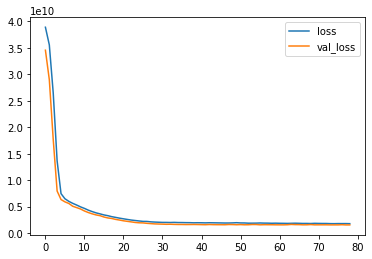

In [36]:
pd.DataFrame(history.history, columns=["loss", "val_loss"]).plot()

<AxesSubplot:>

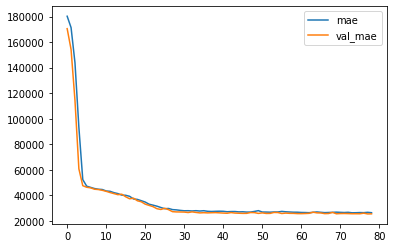

In [37]:
pd.DataFrame(history.history, columns=["mae", "val_mae"]).plot()

<AxesSubplot:>

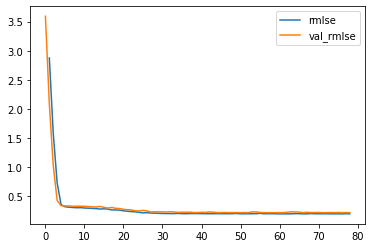

In [38]:
pd.DataFrame(history.history, columns=["rmlse", "val_rmlse"]).plot()

In [39]:
export_result(neural_network_model_1, test_dummied, "submission_neural_network_model_1.csv")

### Train Deep Neural Network Model with with correlated features

In [40]:
x_train_subset = x_train_dummied[correlated_features]
x_val_subset = x_val_dummied[correlated_features]
neural_network_model_2 = tf.keras.Sequential([
    tf.keras.Input(shape=(x_train_subset.shape[1])),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2()),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2()),
    tf.keras.layers.Dense(1)
])
early_stop = tf.keras.callbacks.EarlyStopping(patience=20)
neural_network_model_2_checkpoint = "neural_network_model_2.h5"
checkpoint = tf.keras.callbacks.ModelCheckpoint(neural_network_model_2_checkpoint, save_best_only=True)
neural_network_model_2.compile(loss="mse", optimizer="adam", metrics=[
    "mse", "mae", "mape", rmlse
])
history = neural_network_model_2.fit(
    x_train_subset, y_train, epochs=100, 
    validation_data=(x_val_subset, y_val),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/100
37/37 [==============================] - 1s 10ms/step - loss: 37335301281.6842 - mse: 37335301281.6842 - mae: 177991.8450 - mape: 98.2699 - rmlse: 4.2680 - val_loss: 33437515776.0000 - val_mse: 33437515776.0000 - val_mae: 167445.0625 - val_mape: 95.1465 - val_rmlse: 3.1252
Epoch 2/100
37/37 [==============================] - 0s 3ms/step - loss: 36288590201.2632 - mse: 36288590201.2632 - mae: 172052.3158 - mape: 93.6366 - rmlse: 2.8853 - val_loss: 28184385536.0000 - val_mse: 28184385536.0000 - val_mae: 151700.3125 - val_mape: 85.2304 - val_rmlse: 2.0010
Epoch 3/100
37/37 [==============================] - 0s 3ms/step - loss: 29239781699.3684 - mse: 29239781699.3684 - mae: 153405.2718 - mape: 81.4182 - rmlse: 1.7958 - val_loss: 18091249664.0000 - val_mse: 18091249664.0000 - val_mae: 115837.2891 - val_mape: 62.3442 - val_rmlse: 1.0637
Epoch 4/100
37/37 [==============================] - 0s 3ms/step - loss: 18897446103.5789 - mse: 18897446103.5789 - mae: 112931.2340 - mape: 56.

**Train Deep Neural Network Model with with correlated scaled features**

In [41]:
x_train_subset = x_train_dummied[correlated_features]
x_val_subset = x_val_dummied[correlated_features]
x_train_subset_scaled = (x_train_subset - mean_value[correlated_features]) / std_value[correlated_features]
x_val_subset_scaled = (x_val_subset - mean_value[correlated_features]) / std_value[correlated_features]
test_dummied_scaled = (test_dummied[correlated_features] - mean_value[correlated_features]) / std_value[correlated_features]

In [42]:
model_dataframe = pd.DataFrame({
        "num_hidden_layers": [
            4, 5, 5, 5
        ], 
        "bottom_hidden_layer_size": [2, 8, 2, 16],
        "hidden_layer_size_growth_strategy": ["double", "same", "double", "same"],
        "hidden_layer_activation": ["relu", "relu", "relu", "relu"],
        "hidden_layer_dropout": [0.5, 0.3, 0.4, 0.2],
        "kernel_regularizer": ["l1", "l2", "l1_l2", "l2"],
        "model_path": ["dnn1.h5", "dnn2.h5", "dnn3.h5", "dnn4.h5"],
        "csv_path": ["dnn1.csv", "dnn2.csv", "dnn3.csv", "dnn4.csv"],
        "val_mse": [0.0, 0.0, 0.0, 0.0],
        "val_mae": [0.0, 0.0, 0.0, 0.0],
        "val_mape": [0.0, 0.0, 0.0, 0.0],
        "val_rmlse": [0.0, 0.0, 0.0, 0.0]
})

In [43]:
model_dataframe.head()

,num_hidden_layers,bottom_hidden_layer_size,hidden_layer_size_growth_strategy,hidden_layer_activation,hidden_layer_dropout,kernel_regularizer,model_path,csv_path,val_mse,val_mae,val_mape,val_rmlse
0,4,2,double,relu,0.5,l1,dnn1.h5,dnn1.csv,0.0,0.0,0.0,0.0
1,5,8,same,relu,0.3,l2,dnn2.h5,dnn2.csv,0.0,0.0,0.0,0.0
2,5,2,double,relu,0.4,l1_l2,dnn3.h5,dnn3.csv,0.0,0.0,0.0,0.0
3,5,16,same,relu,0.2,l2,dnn4.h5,dnn4.csv,0.0,0.0,0.0,0.0


In [44]:
import matplotlib.pyplot as plt
def train_model(
    x_train,
    y_train,
    x_val,
    y_val,
    test, 
    Id,
    df
):
    for i in range(len(df)):
        num_hidden_layers = df.loc[i, "num_hidden_layers"]
        bottom_hidden_layer_size = df.loc[i, "bottom_hidden_layer_size"]
        hidden_layer_size_growth_strategy = df.loc[i, "hidden_layer_size_growth_strategy"]
        hidden_layers = []
        if hidden_layer_size_growth_strategy == "same":
            hidden_layers = [bottom_hidden_layer_size] * num_hidden_layers
        if hidden_layer_size_growth_strategy == "double":
            hidden_layers = list(bottom_hidden_layer_size * np.power(2, np.arange(4)))
            hidden_layers.reverse()
        hidden_layers_activation = df.loc[i, "hidden_layer_activation"]
        hidden_layer_dropout = df.loc[i, "hidden_layer_dropout"]
        kernel_regularizer = df.loc[i, "kernel_regularizer"]
        model_path = df.loc[i, "model_path"]
        print(model_path)
        csv_path = df.loc[i, "csv_path"]
        if kernel_regularizer == "l1":
            kernel_regularizer = tf.keras.regularizers.l1()
        elif kernel_regularizer == "l2":
            kernel_regularizer = tf.keras.regularizers.l2()
        elif kernel_regularizer == "l1_l2":
            kernel_regularizer = tf.keras.regularizers.l1_l2()
        tf.keras.backend.clear_session()
        model = tf.keras.Sequential()
        model.add(tf.keras.Input(shape=(x_train.shape[1])))
        for index, layer in enumerate(hidden_layers):
            model.add(
                tf.keras.layers.Dense(
                    layer, 
                    activation=hidden_layers_activation, 
                    kernel_regularizer=kernel_regularizer
                )
            )
            if hidden_layer_dropout != 0:
                model.add(
                    tf.keras.layers.Dropout(hidden_layer_dropout)
                )
        model.add(tf.keras.layers.Dense(1))
        early_stop = tf.keras.callbacks.EarlyStopping(patience=10)
        checkpoint = tf.keras.callbacks.ModelCheckpoint(model_path, save_best_only=True)
        model.compile(loss="mse", optimizer="adam", metrics=[
            "mse", "mae", "mape", rmlse
        ])
        history = model.fit(
            x_train, y_train, epochs=100, 
            validation_data=(x_val, y_val),
            callbacks=[early_stop, checkpoint],
            verbose=0
        )
        model.load_weights(model_path)
        best_index = np.argmin(history.history["val_rmlse"])
        metrics=["mse", "mae", "mape", "rmlse"]
        for metric in metrics:
            val_metric = "val_" + metric
            df.loc[i, val_metric] = history.history[val_metric][best_index]
            print(val_metric, history.history[val_metric][best_index])
            pd.DataFrame(history.history, columns=[metric, val_metric]).plot()
            plt.show()
        SalePrice = model.predict(test)
        submission = pd.DataFrame({"Id": Id, "SalePrice": SalePrice.reshape(-1)})
        submission.to_csv(csv_path, index=False)

dnn1.h5
val_mse 18866345984.0


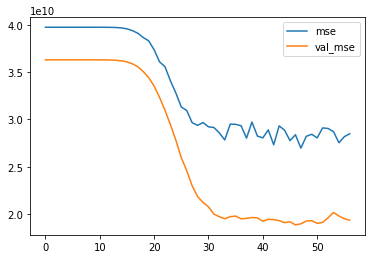

val_mae 123736.2890625


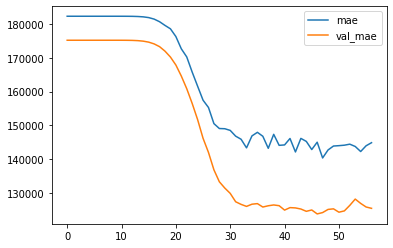

val_mape 68.93292236328125


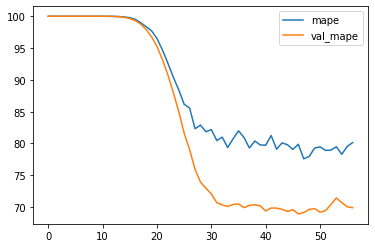

val_rmlse 1.2885730266571045


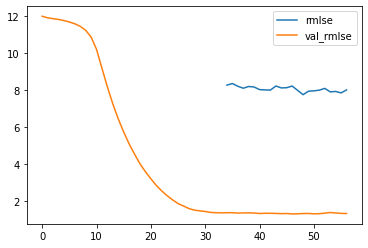

dnn2.h5
val_mse 3570372608.0


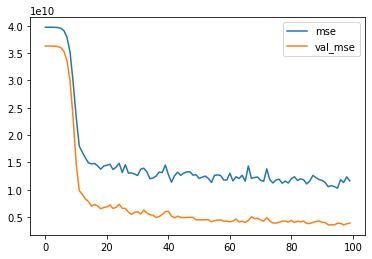

val_mae 46143.9765625


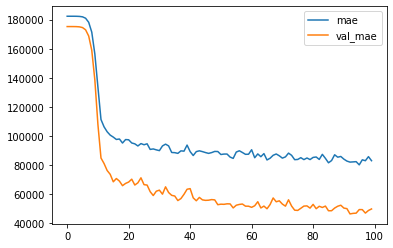

val_mape 25.469614028930664


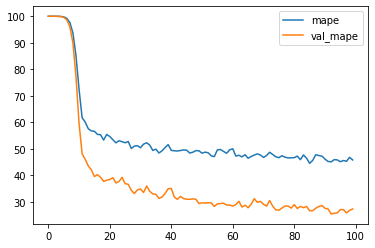

val_rmlse 0.36484062671661377


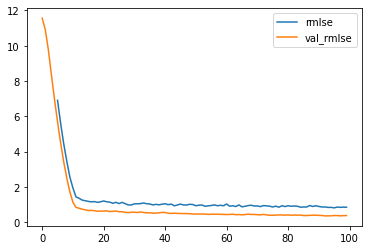

dnn3.h5
val_mse 9403754496.0


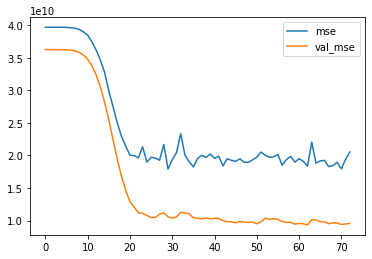

val_mae 83615.6953125


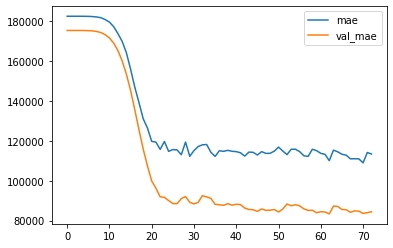

val_mape 46.05231857299805


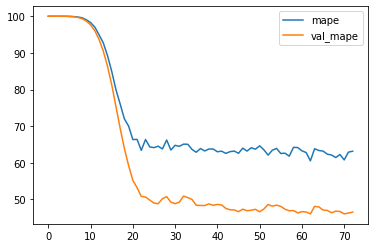

val_rmlse 0.7262719869613647


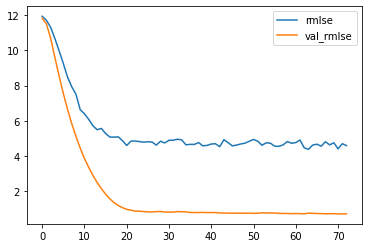

dnn4.h5
val_mse 1318283776.0


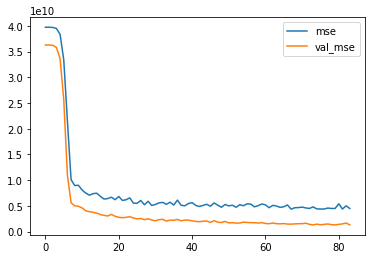

val_mae 25396.86328125


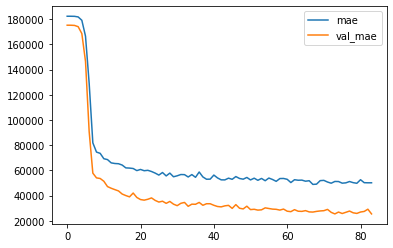

val_mape 15.28354549407959


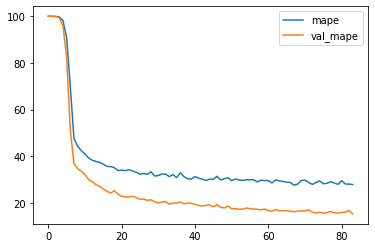

val_rmlse 0.2115776091814041


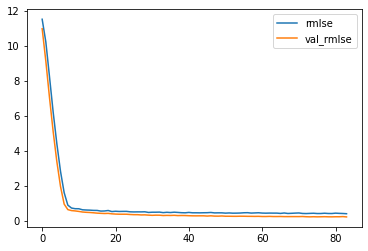

In [45]:
train_model(
    x_train_subset_scaled,
    y_train,
    x_val_subset_scaled,
    y_val,
    test_dummied_scaled, 
    test["Id"],
    model_dataframe
)

## Best DNN Model

In [46]:
model_dataframe.head()

,num_hidden_layers,bottom_hidden_layer_size,hidden_layer_size_growth_strategy,hidden_layer_activation,hidden_layer_dropout,kernel_regularizer,model_path,csv_path,val_mse,val_mae,val_mape,val_rmlse
0,4,2,double,relu,0.5,l1,dnn1.h5,dnn1.csv,1.886635e+10,123736.289062,68.932922,1.288573
1,5,8,same,relu,0.3,l2,dnn2.h5,dnn2.csv,3.570373e+09,46143.976562,25.469614,0.364841
2,5,2,double,relu,0.4,l1_l2,dnn3.h5,dnn3.csv,9.403754e+09,83615.695312,46.052319,0.726272
3,5,16,same,relu,0.2,l2,dnn4.h5,dnn4.csv,1.318284e+09,25396.863281,15.283545,0.211578


In [47]:
model_dataframe.sort_values(ascending=True, by="val_rmlse", inplace=True)
model_dataframe[["model_path", "val_mse" , "val_mae", "val_mape", "val_rmlse"]].head()

,model_path,val_mse,val_mae,val_mape,val_rmlse
3,dnn4.h5,1.318284e+09,25396.863281,15.283545,0.211578
1,dnn2.h5,3.570373e+09,46143.976562,25.469614,0.364841
2,dnn3.h5,9.403754e+09,83615.695312,46.052319,0.726272
0,dnn1.h5,1.886635e+10,123736.289062,68.932922,1.288573


In [48]:
submission = pd.read_csv(model_dataframe.loc[0, "csv_path"])
submission.to_csv("submission.csv", index=False)